# Progetto di Apprendimento Automatico e Apprendimento Profondo

**Studente:** Astolfi Gabriele  
**Matricola:** 0322600084  
**Corso di Laurea:** Magistrale in Ingegneria Informatica e IA Applicata  
**Dataset Scelto:** Statlog (Shuttle) Dataset (UCI ID: 148)

### Introduzione e Obiettivo del Progetto
Il progetto si basa sullo studio e l'analisi dei dati di telemetria reali provenienti dai sensori di uno Space Shuttle della NASA. L'obiettivo è quello di implementare e confrontare diversi modelli di Machine Learning e Deep Learning per il monitoraggio dello stato operativo del veicolo spaziale e l'identificazione automatica delle anomalie di bordo (classificazione multiclasse).



In [1]:
import pandas as pd

# 1. Definisco i nomi ufficiali delle colonne dello Shuttle
nomi_colonne = [
    'Sensore_1', 'Sensore_2', 'Sensore_3', 'Sensore_4',
    'Sensore_5', 'Sensore_6', 'Sensore_7', 'Sensore_8',
    'Sensore_9', 'Classe'
]

print("--- CARICAMENTO LOCALE DEL FILE DI TEST  ---")

# Leggiamo solo il file .tst che è in formato testo
dataset_shuttle = pd.read_csv('shuttle.tst', sep=r'\s+', names=nomi_colonne)

print("File letto con successo.")

# 2. Salvo il dataset in un formato CSV standard
dataset_shuttle.to_csv('shuttle_completo.csv', index=False)
print("File salvato nella cartella del progetto come: 'shuttle_completo.csv'")

# 3. Ispezione dei dati caricati
print("\n--- INFO SUL DATASET CARICATO ---")
print(f"Numero totale di righe (campioni): {dataset_shuttle.shape[0]}")
print(f"Numero totale di colonne (feature + classe): {dataset_shuttle.shape[1]}")

print("\nPrime 5 righe delle letture dei sensori dello Shuttle:")
print(dataset_shuttle.head())

print("\nDistribuzione delle classi (quante anomalie ci sono in queste 14.500 righe):")
print(dataset_shuttle['Classe'].value_counts().sort_index())


--- CARICAMENTO LOCALE DEL FILE DI TEST  ---
File letto con successo.
File salvato nella cartella del progetto come: 'shuttle_completo.csv'

--- INFO SUL DATASET CARICATO ---
Numero totale di righe (campioni): 14500
Numero totale di colonne (feature + classe): 10

Prime 5 righe delle letture dei sensori dello Shuttle:
   Sensore_1  Sensore_2  Sensore_3  Sensore_4  Sensore_5  Sensore_6  \
0         55          0         81          0         -6         11   
1         56          0         96          0         52         -4   
2         50         -1         89         -7         50          0   
3         53          9         79          0         42         -2   
4         55          2         82          0         54         -6   

   Sensore_7  Sensore_8  Sensore_9  Classe  
0         25         88         64       4  
1         40         44          4       4  
2         39         40          2       1  
3         25         37         12       4  
4         26         28     

## Task 1: Partizionamento dei Dati, Standardizzazione e Analisi PCA

In questa sezione il dataset viene suddiviso manualmente in tre subset: Training Set (70%), Validation Set (15%) e Test Set (15%).

Prima di applicare la PCA, le feature vengono standardizzate tramite `StandardScaler` per azzerare la media e bloccare la varianza a uno, eliminando le discrepanze di scala tra i diversi sensori. Successivamente, viene implementata la PCA (Principal Component Analysis) riducendo le dimensioni a 2 componenti principali per visualizzare graficamente la distribuzione e la separabilità delle anomalie nello spazio geometrico.


--- TASK 1: DIVISIONE DATI, STANDARDIZZAZIONE E PCA ---
Dataset originale splitto manualmente in:
 - Training Set:   (10150, 9) campioni (70%)
 - Validation Set: (2175, 9) campioni (15%)
 - Test Set:       (2175, 9) campioni (15%)

📈 Le prime 2 Componenti Principali spiegano il 52.77% della varianza totale dei sensori!
Grafico salvato nella cartella del progetto come 'shuttle_pca_plot.png'.


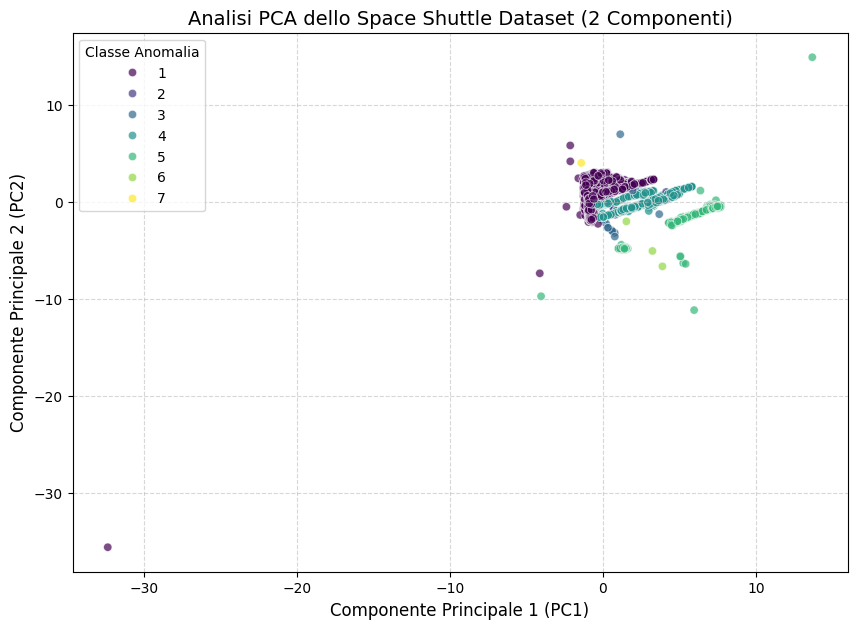

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("--- TASK 1: DIVISIONE DATI, STANDARDIZZAZIONE E PCA ---")

# 1. Carico il dataset
df = pd.read_csv('shuttle_completo.csv')

# Separo le feature (X, i 9 sensori) dalla variabile target (y, la classe di anomalia)
X = df.drop(columns=['Classe'])
y = df['Classe']

# 2. Suddivisione manuale
# Primo split: separo il 70% di Training dal restante 30%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Secondo split: divido il 30% temporaneo a metà (15% Validation e 15% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Dataset originale splitto manualmente in:")
print(f" - Training Set:   {X_train.shape} campioni (70%)")
print(f" - Validation Set: {X_val.shape} campioni (15%)")
print(f" - Test Set:       {X_test.shape} campioni (15%)")

# 3. Standardizzazione (prima della PCA)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 4. Applicazione della PCA (riduco da 9 dimensioni a 2 per visualizzarle)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

varianza_spiegata = np.sum(pca.explained_variance_ratio_) * 100
print(f"\n📈 Le prime 2 Componenti Principali spiegano il {varianza_spiegata:.2f}% della varianza totale dei sensori!")

# 5. Creazione del Grafico 2D della PCA
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette='viridis',
    alpha=0.7,
    legend='full'
)

plt.title('Analisi PCA dello Space Shuttle Dataset (2 Componenti)', fontsize=14)
plt.xlabel('Componente Principale 1 (PC1)', fontsize=12)
plt.ylabel('Componente Principale 2 (PC2)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Classe Anomalia')

# Salvo il grafico come immagine sul PC
plt.savefig('shuttle_pca_plot.png', dpi=300)
print("Grafico salvato nella cartella del progetto come 'shuttle_pca_plot.png'.")

# Mostro il grafico a schermo
plt.show()


## Task 2 & 3: Modelli di Classificazione Classica e Calcolo delle Metriche

In questa sezione vengono addestrati tre algoritmi di classificazione classica (Shallow Learning): Logistic Regression (utilizzato come baseline), Random Forest Classifier e K-Nearest Neighbors (KNN).

Le metriche di valutazione (Accuracy, Precision, Recall e F-Measure) vengono calcolate sul Test Set. Trattandosi di un problema multiclasse sbilanciato, le metriche di Precision, Recall e F-Measure vengono calcolate applicando una media pesata (`average='weighted'`).


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("--- TASK 2 & 3: ADDESTRAMENTO MODELLI E CALCOLO METRICHE ---")

# 1. Preparo i dati  come nel Task 1
df = pd.read_csv('shuttle_completo.csv')
X = df.drop(columns=['Classe'])
y = df['Classe']

# Rieseguo lo split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Standardizzo i dati (per Logistic Regression e KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Inizializzo i 3 algoritmi scelti
modelli = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
}

# Dizionario per salvare i risultati da stampare in una tabella per la relazione
risultati = []

# 3. Loop per addestrare e valutare ogni modello
for nome, modello in modelli.items():
    print(f"\nAddestramento di {nome} in corso...")
    modello.fit(X_train_scaled, y_train)

    # Predizioni delle classi
    y_pred = modello.predict(X_test_scaled)
    # Predizioni delle probabilità (necessarie per la ROC AUC)
    y_proba = modello.predict_proba(X_test_scaled)

    # Calcolo delle metriche (uso average='macro' o 'weighted' perché è un problema multiclasse)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Per la ROC AUC multiclasse uso l'approccio One-Vs-Rest (ovr)
    try:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except Exception:
        auc = np.nan  # Protezione in caso qualche classe mancasse nel subset di test

    risultati.append({
        "Modello": nome,
        "Accuracy": f"{acc * 100:.2f}%",
        "Precision": f"{prec * 100:.2f}%",
        "Recall": f"{rec * 100:.2f}%",
        "F-Measure": f"{f1 * 100:.2f}%",
        "ROC AUC": f"{auc:.4f}" if not np.isnan(auc) else "N/A"
    })

# 4. Mostro i risultati finali in una tabella
df_risultati = pd.DataFrame(risultati)
print("\n================ TABELLA COMPARATIVA DELLE METRICHE ================")
print(df_risultati.to_string(index=False))
print("====================================================================")


--- TASK 2 & 3: ADDESTRAMENTO MODELLI E CALCOLO METRICHE ---

Addestramento di Logistic Regression in corso...

Addestramento di Random Forest in corso...

Addestramento di K-Nearest Neighbors in corso...

================ TABELLA COMPARATIVA DELLE METRICHE ================
            Modello Accuracy Precision Recall F-Measure ROC AUC
Logistic Regression   96.97%    96.61% 96.97%    96.77%     N/A
      Random Forest   99.95%    99.95% 99.95%    99.95%     N/A
K-Nearest Neighbors   99.68%    99.54% 99.68%    99.61%     N/A


## Task 4: Visualizzazione Grafica dei Risultati (Confusion Matrix e Curve ROC)

Per analizzare nel dettaglio il comportamento del miglior classificatore riscontrato (Random Forest), vengono generate la Matrice di Confusione e le Curve ROC (Receiver Operating Characteristic) calcolate per ogni classe presente tramite strategia One-Vs-Rest.


--- TASK 4: GENERAZIONE MATRICE DI CONFUSIONE E CURVA ROC ---
Generazione della Matrice di Confusione...
Matrice di confusione salvata come 'shuttle_confusion_matrix.png'
Generazione della Curva ROC...
Curva ROC salvata come 'shuttle_roc_curve.png'


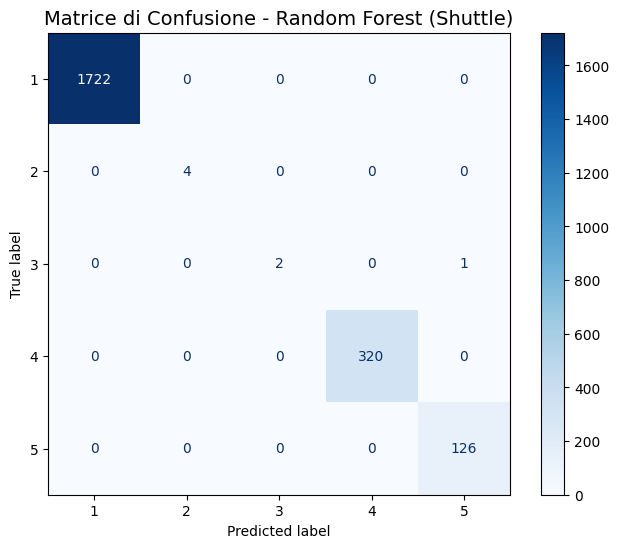

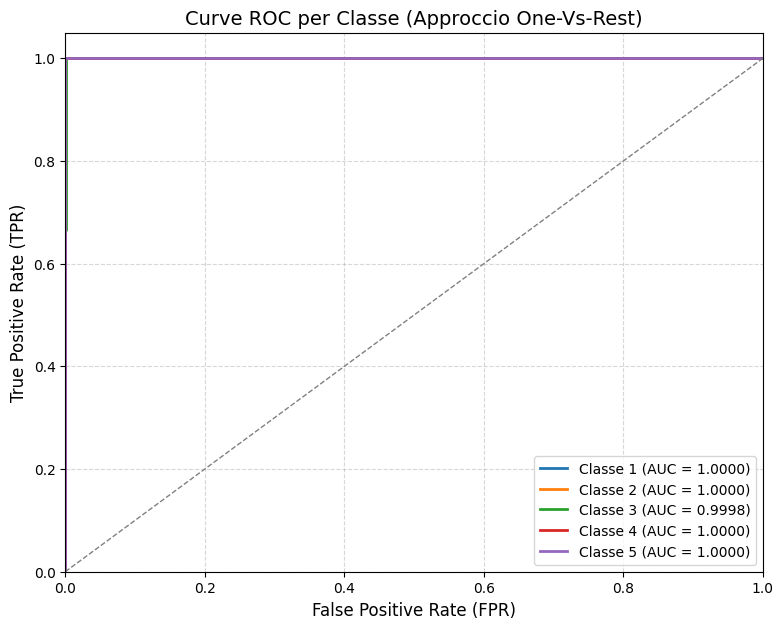

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

print("--- TASK 4: GENERAZIONE MATRICE DI CONFUSIONE E CURVA ROC ---")

# 1. Preparo i dati
df = pd.read_csv('shuttle_completo.csv')
X = df.drop(columns=['Classe'])
y = df['Classe']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Alleno il modello: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)

# --- PARTE A: MATRICE DI CONFUSIONE ---
print("Generazione della Matrice di Confusione...")
cm = confusion_matrix(y_test, y_pred)
# classi presenti nel test set per evitare sfasamenti nei grafici
classi_presenti = np.unique(y_test)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classi_presenti)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matrice di Confusione - Random Forest (Shuttle)', fontsize=14)

# Salviamo l'immagine per la relazione
plt.savefig('shuttle_confusion_matrix.png', dpi=300)
print("Matrice di confusione salvata come 'shuttle_confusion_matrix.png'")

# --- PARTE B: CURVA ROC MULTICLASSE (Risoluzione del problema N/A) ---
print("Generazione della Curva ROC...")
y_test_bin = label_binarize(y_test, classes=classi_presenti)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(9, 7))

# Calcolo e disegno la curva ROC per ogni classe disponibile
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Classe {classi_presenti[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Curve ROC per Classe (Approccio One-Vs-Rest)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)

# Salvo la seconda immagine per la relazione
plt.savefig('shuttle_roc_curve.png', dpi=300)
print("Curva ROC salvata come 'shuttle_roc_curve.png'")

# Mostro i grafici a schermo
plt.show()


## Task 5: Approccio di Deep Learning (Multi-Layer Perceptron)

Seguendo il punto 5.a della traccia, viene implementata un'architettura di Deep Learning basata su una Rete Neurale Artificiale di tipo Multi-Layer Perceptron (MLP).
Il modello è configurato con due strati nascosti (rispettivamente da 64 e 32 neuroni), utilizzando la funzione di attivazione ReLU (Rectified Linear Unit) per l'introduzione di non-linearità e l'ottimizzatore stocastico Adam per l'aggiornamento dei pesi tramite Backpropagation. Le prestazioni finali vengono misurate sul Test Set per effettuare una comparazione diretta con i modelli classici analizzati in precedenza.


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("--- TASK 5.a: IMPLEMENTAZIONE APPROACH DI DEEP LEARNING (MLP) ---")

# 1. Carico i dati
df = pd.read_csv('shuttle_completo.csv')
X = df.drop(columns=['Classe'])
y = df['Classe']

# Estraggo il Training (70%), Validation (15%) e Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Standardizzazione per evitare che il gradiente esploda o svanisca
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 2. Configurazione dell'architettura della Rete Neurale (Multi-Layer Perceptron)
print("\nInizializzazione della Rete Neurale Profonda...")
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # Due strati nascosti: 64 neuroni e poi 32 neuroni
    activation='relu',            # Funzione di attivazione ReLU per introdurre non-linearità
    solver='adam',                # Ottimizzatore Adam (il top studiato al Capitolo 33)
    max_iter=500,                 # Numero massimo di epoche di addestramento
    random_state=42,              # Blocco del seed casuale per la riproducibilità
    verbose=True                  # Stampa la perdita (loss) a ogni epoca per monitorare il progresso
)

# 3. Addestramento della Rete Neurale
print("Inizio addestramento (Backpropagation in corso)...")
mlp.fit(X_train_scaled, y_train)

# 4. Valutazione sul Test Set per calcolare le metriche di confronto
y_pred_mlp = mlp.predict(X_test_scaled)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, average='weighted', zero_division=0)
rec_mlp = recall_score(y_test, y_pred_mlp, average='weighted', zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0)

# 5. Stampa del report finale da inserire nelle conclusioni della tua relazione
print("\n================ METRICHE FINALI - DEEP LEARNING (MLP) ================")
print(f"Accuracy  DL: {acc_mlp*100:.2f}%")
print(f"Precision DL: {prec_mlp*100:.2f}%")
print(f"Recall    DL: {rec_mlp*100:.2f}%")
print(f"F-Measure DL: {f1_mlp*100:.2f}%")
print("=======================================================================")



--- TASK 5.a: IMPLEMENTAZIONE APPROACH DI DEEP LEARNING (MLP) ---

Inizializzazione della Rete Neurale Profonda...
Inizio addestramento (Backpropagation in corso)...
Iteration 1, loss = 1.15530790
Iteration 2, loss = 0.34230674
Iteration 3, loss = 0.19045188
Iteration 4, loss = 0.13823036
Iteration 5, loss = 0.10713166
Iteration 6, loss = 0.08687614
Iteration 7, loss = 0.07223378
Iteration 8, loss = 0.06045995
Iteration 9, loss = 0.05124533
Iteration 10, loss = 0.04469694
Iteration 11, loss = 0.03995393
Iteration 12, loss = 0.03689256
Iteration 13, loss = 0.03414919
Iteration 14, loss = 0.03178863
Iteration 15, loss = 0.03032743
Iteration 16, loss = 0.02887323
Iteration 17, loss = 0.02735274
Iteration 18, loss = 0.02579614
Iteration 19, loss = 0.02501331
Iteration 20, loss = 0.02412762
Iteration 21, loss = 0.02274216
Iteration 22, loss = 0.02207820
Iteration 23, loss = 0.02130672
Iteration 24, loss = 0.02087915
Iteration 25, loss = 0.02010246
Iteration 26, loss = 0.01951899
Iteration 2